In [13]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


balanced = pd.read_csv("balanced_log.csv")
balanced

,center,left,right,steering,throttle,brake,speed
0,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.05,1.0,0,30.19068
1,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19069
2,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19027
3,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.18975
4,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.10,1.0,0,30.18807
...,...,...,...,...,...,...,...
2607,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.85,1.0,0,30.10747
2608,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.15,1.0,0,30.18419
2609,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.18972
2610,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.10,1.0,0,30.18936


# Data Augmentation

- slight right bias
- removed overabundance of "straight" frames and rows
- only included rows where the throttle was fully pressed
- **Data collection was done using keyboard keys (may need to retry with mouse steering)**


## Data Split

In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced, test_size=0.2, random_state=42
)
# fix the indices, drop index column
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
val_df


,center,left,right,steering,throttle,brake,speed
0,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19102
1,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.20,1.0,0,30.17935
2,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.19011
3,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19031
4,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.25,1.0,0,30.17594
...,...,...,...,...,...,...,...
518,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.20,1.0,0,30.18223
519,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.15,1.0,0,30.18983
520,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.30,1.0,0,30.17288
521,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.15,1.0,0,30.18617


## Apply Augmentations

### Testing Augments
- for testing, i used ai generated code.

['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
D:\DPS 920\DPS920_final_project\IMG\center_2026_07_28_11_07_40_113.jpg


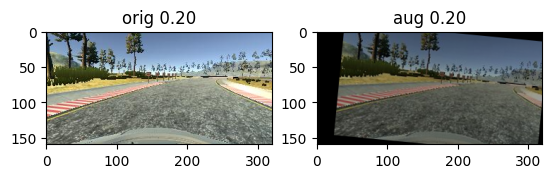

In [15]:
import cv2
import matplotlib.pyplot as plt
from augmentations import random_augment

print(train_df.columns.tolist())  # must include 'center'

row = train_df.iloc[0]
path = row["center"]              # quotes required
print(path)

img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(path)

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img2, steer2 = random_augment(img, float(row["steering"]))

plt.subplot(1, 2, 1); plt.imshow(img); plt.title(f"orig {row['steering']:.2f}")
plt.subplot(1, 2, 2); plt.imshow(img2); plt.title(f"aug {steer2:.2f}")
plt.show()

### Testing PreProcessing

input: (160, 320, 3) output: (66, 200, 3) dtype: float64
min/max: 0.09411764705882353 0.996078431372549


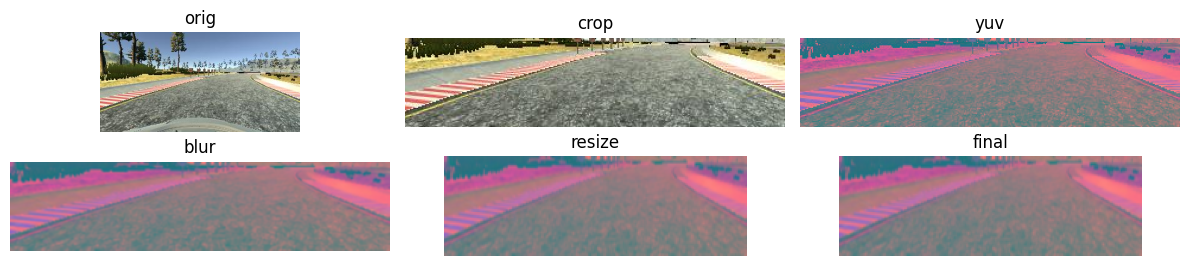

In [16]:
import cv2
import matplotlib.pyplot as plt
from preprocess import preprocess, crop, to_yuv, blur, resize, normalize

row = train_df.iloc[0]
path = row["center"]

img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(path)

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
out = preprocess(img)

print("input:", img.shape, "output:", out.shape, "dtype:", out.dtype)
print("min/max:", out.min(), out.max())  # expect ~0..1 and (66, 200, 3)

# Step-by-step (skip full normalize for display — YUV looks odd but that's OK)
steps = [
    ("orig", img),
    ("crop", crop(img)),
    ("yuv", to_yuv(crop(img))),
    ("blur", blur(to_yuv(crop(img)))),
    ("resize", resize(blur(to_yuv(crop(img))))),
    ("final", out),  # normalized; imshow still works with [0,1]
]

plt.figure(figsize=(12, 4))
for i, (title, im) in enumerate(steps, 1):
    plt.subplot(3, 3, i)
    plt.imshow(im)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

# float YUV [0,1] -> uint8 for cv2; convert YUV->BGR so the window looks normal
out_u8 = np.clip(out * 255, 0, 255).astype(np.uint8)
out_bgr = cv2.cvtColor(out_u8, cv2.COLOR_YUV2BGR)
out_view = cv2.resize(out_bgr, (400, 132), interpolation=cv2.INTER_NEAREST)
# cv2.imshow("original", img_bgr)
# cv2.imshow("final", out_view)
# cv2.waitKey(0)          # press any key to close
# cv2.destroyAllWindows()


# Train Model
- skipping batching for now

## Pre-Processing

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from preprocess import preprocess
from augmentations import random_augment

# DATA
data_list = []
label_list = []

# PRE-PROCESSING (for training data)
for i, row in train_df.iterrows():
    # use only center image
    path = row["center"]
    image = cv2.imread(path)
    if image is None:
        print("Image missing at: ", path)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    steering = float(row["steering"])

    # optional: comment out if you want raw only
    image, steering = random_augment(image, steering)

    image = preprocess(image)   # crop -> YUV -> blur -> resize to 200x66 -> img/255

    data_list.append(image)
    label_list.append(steering)

    if i % 200 == 0:
        print(f"[INFO] {i} images processed!")


val_data_list=[]
val_label_list=[]
# PRE-PROCESSING (for test data)
for i, row in val_df.iterrows():
    # use only center image
    path = row["center"]
    val_img = cv2.imread(path)
    if val_img is None:
        print("Image missing at: ", path)
        continue

    val_img = cv2.cvtColor(val_img, cv2.COLOR_BGR2RGB)
    val_steering = float(row["steering"])

    val_img = preprocess(val_img)   # crop -> YUV -> blur -> resize to 200x66 -> img/255

    val_data_list.append(val_img)
    val_label_list.append(val_steering)

    if i % 100 == 0:
        print(f"[INFO: TEST] {i} images processed!")

# https://www.tensorflow.org/guide/mixed_precision
# Keras/TensorFlow models usually train on float32 (saves memory)
X = np.array(data_list, dtype=np.float32)
y = np.array(label_list, dtype=np.float32)
X_val = np.array(val_data_list, dtype=np.float32)
y_val = np.array(val_label_list, dtype=np.float32)

#  in YUV
print(X.shape, y.shape)  # (N, 66, 200, 3), (N,)
print(X_val.shape, y_val.shape)

[INFO] 0 images processed!
[INFO] 200 images processed!
[INFO] 400 images processed!
[INFO] 600 images processed!
[INFO] 800 images processed!
[INFO] 1000 images processed!
[INFO] 1200 images processed!
[INFO] 1400 images processed!
[INFO] 1600 images processed!
[INFO] 1800 images processed!
[INFO] 2000 images processed!
[INFO: TEST] 0 images processed!
[INFO: TEST] 100 images processed!
[INFO: TEST] 200 images processed!
[INFO: TEST] 300 images processed!
[INFO: TEST] 400 images processed!
[INFO: TEST] 500 images processed!
(2089, 66, 200, 3) (2089,)
(523, 66, 200, 3) (523,)


## Training
### !!!WIP!!!

In [ ]:
from keras import Sequential, layers
from keras.optimizers import Adam
from keras.models import save_model

# WIP BELOW
# MODEL (Nvidia-style CNN — regression, not classification)
model = Sequential([
    layers.Conv2D(24, (5, 5), strides=(2, 2), activation="relu", input_shape=(66, 200, 3)),
    layers.Conv2D(36, (5, 5), strides=(2, 2), activation="relu"),
    layers.Conv2D(48, (5, 5), strides=(2, 2), activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    # last layer is the number of classes you have
    layers.Dense(1),  # steering angle
])
# MAE is more robust to outliers than MSE
# MAE is not differentiable
# MSE is sensitive to outliers
# Huber Loss
# Log-Cosh Loss
# stochastic G descent: drunk man going down hill.
# stochastic G descent: batch up the data, update all weights once, move onto next batch
# at the end you end up at SOME local minimum
model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
# change batching
H = model.fit(X, y, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# EVALUATE
plt.plot(H.history["loss"], label="loss")
plt.plot(H.history["val_loss"], label="val loss")
plt.legend()
plt.show()

save_model(model, "model.h5")